In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud


In [44]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\DHARM
[nltk_data]     SHAH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\DHARM
[nltk_data]     SHAH\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\DHARM
[nltk_data]     SHAH\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\DHARM
[nltk_data]     SHAH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [45]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

In [46]:
df = pd.DataFrame(data)

df.head(10)

,Review
0,The product quality is excellent and delivery ...
1,Very bad packaging and the item was damaged.
2,Customer service was helpful and responsive.
3,The delivery was delayed and support team did ...
4,Amazing product. Worth the money.
5,Poor quality product and terrible experience.
6,Fast shipping and good packaging.
7,The product stopped working after two days.
8,Excellent service and great quality.
9,Late delivery and bad customer support.


In [47]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [48]:
print(clean_text(df['Review'].iloc[0]))
print(clean_text(df['Review'].iloc[2]))

['product', 'quality', 'excellent', 'delivery', 'fast']
['customer', 'service', 'helpful', 'responsive']


In [49]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(text):
    score = sia.polarity_scores(text)
    compound_score = score['compound']
    if compound_score >= 0.05:
        sentiment = 'Positive'
    elif compound_score <= -0.05:
        sentiment = 'Negative'
    else:
        sentiment = 'Neutral'
        
    return sentiment
df['Sentiment'] = df['Review'].apply(analyze_sentiment)


In [50]:
analyze_sentiment(df['Review'].iloc[0])

'Positive'

In [51]:
print("Sentiment Analysis for All Reviews:\n")
print("=" * 80)

for idx, review in enumerate(df['Review'], 1):
    sentiment_scores = sia.polarity_scores(review)
    sentiment_label = analyze_sentiment(review)
    
    print(f"\nReview {idx}: {review}")
    print(f"Sentiment: {sentiment_label}")
    print(f"Scores - Positive: {sentiment_scores['pos']:.3f}, Negative: {sentiment_scores['neg']:.3f}, Neutral: {sentiment_scores['neu']:.3f}, Compound: {sentiment_scores['compound']:.3f}")
    print("-" * 80)

Sentiment Analysis for All Reviews:


Review 1: The product quality is excellent and delivery was very fast.
Sentiment: Positive
Scores - Positive: 0.291, Negative: 0.000, Neutral: 0.709, Compound: 0.572
--------------------------------------------------------------------------------

Review 2: Very bad packaging and the item was damaged.
Sentiment: Negative
Scores - Positive: 0.000, Negative: 0.527, Neutral: 0.473, Compound: -0.771
--------------------------------------------------------------------------------

Review 3: Customer service was helpful and responsive.
Sentiment: Positive
Scores - Positive: 0.570, Negative: 0.000, Neutral: 0.430, Compound: 0.649
--------------------------------------------------------------------------------

Review 4: The delivery was delayed and support team did not respond.
Sentiment: Positive
Scores - Positive: 0.214, Negative: 0.151, Neutral: 0.635, Compound: 0.202
--------------------------------------------------------------------------------

Rev

In [52]:
df['Clean_Review'] = df['Review'].apply(lambda x: ' '.join(clean_text(x)))

In [53]:
all_words = "".join(df['Clean_Review'])

word_list = all_words.split()

word_freq = Counter(word_list)

print("\nTop 10 Common Keywords:")
print(word_freq.most_common(10))


Top 10 Common Keywords:
[('product', 3), ('quality', 2), ('delivery', 2), ('service', 2), ('support', 2), ('excellent', 1), ('fastbad', 1), ('packaging', 1), ('item', 1), ('damagedcustomer', 1)]


In [54]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = " ".join(negative_reviews['Clean_Review'])
negative_word_list = negative_words.split() 
complaint_word_freq = Counter(negative_word_list)

print(complaint_word_freq.most_common(10))

[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


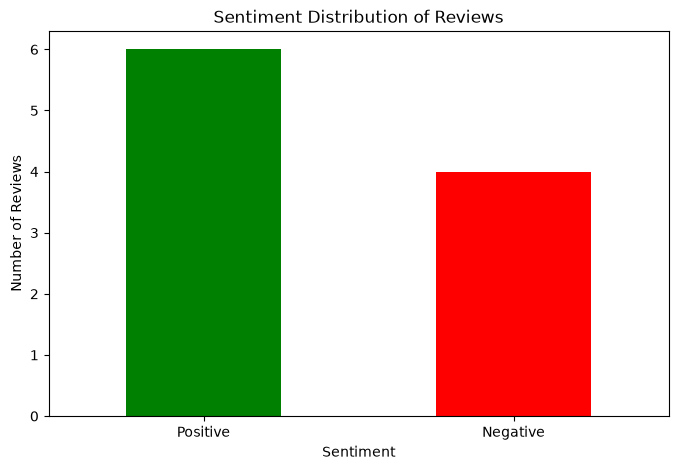

In [55]:
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution of Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

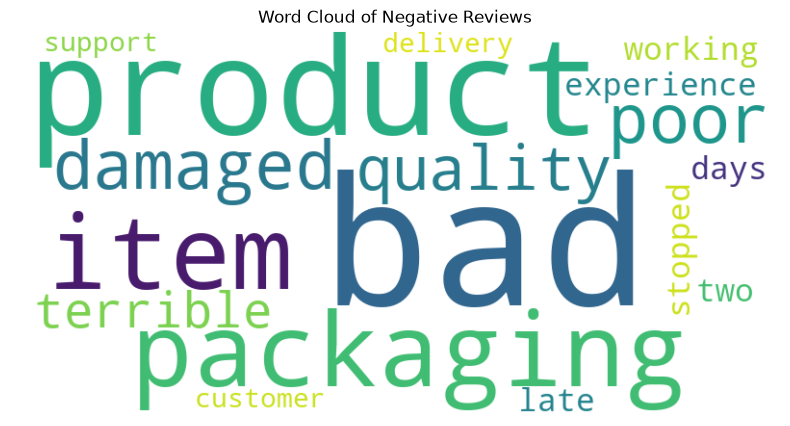

In [56]:
WordCloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(complaint_word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(WordCloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Reviews')
plt.show()